---
tags: [algorithm, machine-learning, variational]
---

# Hybrid Quantum Neural Network (HQNN)

This tutorial presents an example of implementing a **Hybrid Quantum Neural Network** (HQNN), which combines a classical neural network with a variational quantum circuit, using Qamomile. For an image-recognition task on the Fashion-MNIST dataset, we train a four-qubit quantum circuit using gradients computed with the parameter shift rule and demonstrate that the trained HQNN can classify images in the dataset.

In [1]:
# Install the latest Qamomile through pip!
# !pip install "qamomile[qiskit,visualization]" torch torchvision

In [2]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from torchvision import datasets, transforms

import qamomile.circuit as qmc
import qamomile.observable as qmo
from qamomile.circuit.algorithm import cz_entangling_layer, ry_layer, rz_layer
from qamomile.qiskit import QiskitTranspiler, hamiltonian_to_sparse_pauli_op

docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"

## Background: Image Recognition and Machine Learning

### Convolutional Neural Networks (CNNs)

A neural network is a machine-learning model that produces a prediction by transforming an input through a sequence of layers. If $\mathbf{h}^{(0)}=\mathbf{x}$ denotes the input, layer $l$ computes

$$
\mathbf{h}^{(l)} = \phi^{(l)}\!\left(
    W^{(l)}\mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}
\right), \qquad l=1,\ldots,L,
$$

where $W^{(l)}$ and $\mathbf{b}^{(l)}$ are trainable weights and biases, and $\phi^{(l)}$ is a nonlinear activation function. For classification, the final representation gives the predicted class probabilities through

$$
\hat{\mathbf{y}}
= \operatorname{softmax}\!\left(
    W_{\mathrm{out}}\mathbf{h}^{(L)} + \mathbf{b}_{\mathrm{out}}
\right).
$$

Training computes a loss from the predictions and target labels, propagates its derivatives backward through the network, and updates the weights and biases in every layer.

Image recognition is a machine-learning task that assigns a class to an input image. Processing an image with fully connected layers alone does not directly exploit spatial relationships between pixels and can require many parameters. A convolutional neural network (CNN) instead shares small filters across the image to extract local patterns such as edges and textures as features. The local region of the image examined by a filter at one time is called its local receptive field. Pooling layers then progressively reduce the spatial resolution. A classifier uses the resulting features to distinguish image classes {cite:p}`10.1038/nature14539`.

### Quantum Neural Networks (QNNs)

A quantum neural network (QNN) can be viewed as a supervised-learning model in which a sequence of parameter-dependent unitary transformations acts on an input quantum state. For binary classification, a Pauli observable is measured on a designated readout qubit, and its output serves as the prediction. A classical optimizer adjusts the unitary parameters so that these predictions approach the training labels. Classical samples must first be encoded as quantum states, but the same framework can also learn labels assigned directly to quantum input states {cite:p}`10.48550/arXiv.1802.06002,10.1038/s41467-020-14454-2`.

A quantum convolutional neural network (QCNN) {cite:p}`10.1038/s41567-019-0648-8` adapts the local receptive fields and weight sharing of a CNN to a quantum circuit. Small image patches are encoded into quantum states, the same parameterized circuit is repeatedly applied as a quantum filter, and measured expectation values form feature maps. Combining such quantum convolutional layers with classical layers makes it possible to construct hybrid image classifiers for current quantum hardware {cite:p}`10.1088/2632-2153/ad2aef`.

## Problem Setting: Fashion-MNIST

[Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) is an image-recognition dataset of $28 \times 28$ grayscale clothing images organized into 10 classes. It contains 60,000 training images and 10,000 test images and is commonly used as a benchmark for comparing image-classification models.

In this tutorial, we select four visually distinct classes (T-shirt, Trouser, Sandal, and Bag) and use 60 training and 30 test samples from each class.

In [3]:
N_CLASSES = 4
SELECTED_CLASSES = [0, 1, 5, 8]  # T-shirt, Trouser, Sandal, Bag
CLASS_NAMES = ["T-shirt", "Trouser", "Sandal", "Bag"]
N_TRAIN_PER_CLASS = 2 if docs_test_mode else 60
N_TEST_PER_CLASS = 2 if docs_test_mode else 30

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,)),
    ]
)

# Use a persistent cache directory to avoid re-downloading
_data_root = os.path.join(os.path.expanduser("~"), ".cache", "fashion_mnist")
full_train = datasets.FashionMNIST(
    root=_data_root, train=True, download=True, transform=transform
)
full_test = datasets.FashionMNIST(
    root=_data_root, train=False, download=True, transform=transform
)


def subset_dataset(dataset, classes, n_per_class):
    """Extract a random subset from the specified classes."""
    images, labels = [], []
    rng_data = np.random.default_rng(0)
    # Use dataset.targets to find indices without loading/transforming all images
    targets = dataset.targets
    if isinstance(targets, torch.Tensor):
        targets = targets.numpy()
    else:
        targets = np.array(targets)
    for new_label, orig_label in enumerate(classes):
        class_indices = np.where(targets == orig_label)[0]
        chosen = rng_data.choice(class_indices, size=n_per_class, replace=False)
        for idx in chosen:
            img, _ = dataset[int(idx)]
            images.append(img)
            labels.append(new_label)
    return torch.stack(images), torch.tensor(labels)


X_train, y_train = subset_dataset(full_train, SELECTED_CLASSES, N_TRAIN_PER_CLASS)
X_test, y_test = subset_dataset(full_test, SELECTED_CLASSES, N_TEST_PER_CLASS)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
# 4 classes x N_PER_CLASS samples each; Fashion-MNIST is 1x28x28 grayscale.
assert X_train.shape == (N_CLASSES * N_TRAIN_PER_CLASS, 1, 28, 28)
assert X_test.shape == (N_CLASSES * N_TEST_PER_CLASS, 1, 28, 28)
print(f"Classes: {CLASS_NAMES}")

Train: torch.Size([240, 1, 28, 28]), Test: torch.Size([120, 1, 28, 28])
Classes: ['T-shirt', 'Trouser', 'Sandal', 'Bag']


## Algorithm

Encoding a high-dimensional image directly into a quantum state and running an expressive QCNN would require many qubits and deep circuits. Because circuits of that scale are impractical on NISQ devices, the image dimensionality must first be reduced to a size that a quantum circuit can accept. We therefore use a classical convolutional block as a front-end feature extractor: it compresses local image features into a small vector, which is then processed by a compact parameterized quantum circuit. This **hybrid quantum neural network (HQNN)** workflow follows the NISQ-oriented strategy of combining dimensionality reduction by a classical CNN with feature transformation by a quantum layer {cite:p}`10.1088/2632-2153/ad2aef`.

In this tutorial, we construct a hybrid algorithm that augments the HQNN workflow with several refinements.

$$
\begin{aligned}
\text{Input image}
&\longrightarrow
\underbrace{\mathrm{CNN}\longrightarrow\text{Sigmoid filter}}
_{\text{Classical convolutional layer}}
\longrightarrow \text{Quantum circuit layer} \\
&\longrightarrow
\underbrace{
    \text{Concatenate outputs}(\text{CNN features},\,\text{quantum output})
    \longrightarrow \text{Classifier}
}_{\text{Classical fully connected layer}}
\longrightarrow \text{Output}
\end{aligned}
$$

In this workflow, a classical convolutional layer extracts $n$ features from an image, a quantum circuit layer transforms them into $m$ expectation values, and a classical fully connected layer predicts probabilities over $K$ classes. The same classification loss trains every component together.

### Classical Convolutional Layer

The classical convolutional layer extracts local patterns from the input image as features and compresses them into an $n$-dimensional feature vector that can be supplied to the quantum circuit.

Let $C$, $H$, and $W$ denote the number of input channels, height, and width, respectively, so that a normalized image is $\mathbf{X} \in \mathbb{R}^{C \times H \times W}$. Each convolution block applies a learned $k_h \times k_w$ filter, an activation function $\phi$, and $p_h \times p_w$ pooling. If $\mathbf{h}^{(0)} = \mathbf{X}$, the $L_{\mathrm{CNN}}$ blocks can be written schematically as

$$
\mathbf{h}^{(l)} = \operatorname{Pool}\!\left(
    \phi\!\left(\mathbf{K}^{(l)} * \mathbf{h}^{(l-1)}
    + \mathbf{b}^{(l)}\right)
\right), \qquad l \in \mathcal{L}_{\mathrm{CNN}},
$$

where $\operatorname{Pool}$ denotes pooling over a $p_h \times p_w$ window, $*$ denotes convolution, and $\mathcal{L}_{\mathrm{CNN}}$ is the index set of convolution blocks. The resulting tensor is flattened and projected to an $n$-dimensional feature vector. These features are converted into quantum rotation angles by

$$
\mathbf{x} = \alpha\,\sigma\!\left(
    W_{\mathrm{CNN}}\operatorname{vec}(\mathbf{h}^{(L_{\mathrm{CNN}})})
    + \mathbf{b}_{\mathrm{CNN}}
\right) \in \mathbb{R}^{n}.
$$

Here, $\sigma$ is a bounded activation function and $\alpha$ sets the angle scale. Bounding every component of $\mathbf{x}$ avoids unnecessarily large rotation angles and the resulting wrap-around during training.

### Quantum Circuit Layer

The quantum circuit layer encodes the features extracted by the classical convolutional layer into a quantum state, transforms them with a variational quantum circuit, and outputs the result as $m$ expectation values.

The $n$ CNN features are encoded into $n$ qubits with RY rotations. If $\mathcal{Q}$ denotes the qubit index set, the encoding unitary is

$$
U_{\mathrm{enc}}(\mathbf{x})
= \prod_{i \in \mathcal{Q}} R_{Y,i}(x_i).
$$

A variational circuit $V(\boldsymbol{\theta})$ with $L_{\mathrm{Q}}$ layers then applies trainable RZ-RY-RZ rotations to every qubit followed by a linear chain of CZ gates. The resulting state is

$$
|\psi(\mathbf{x},\boldsymbol{\theta})\rangle
= V(\boldsymbol{\theta})U_{\mathrm{enc}}(\mathbf{x})
|\mathbf{0}\rangle_{\mathcal{Q}},
$$

If each layer has $d$ trainable rotation parameters per qubit ($d=3$ here, for RZ–RY–RZ), the circuit has $L_{\mathrm{Q}} \times n \times d$ quantum parameters. Let $\mathcal{O}$ be an index set of observables. The quantum output is the vector of Pauli-$Z$ expectation values

$$
q_j = \langle\psi(\mathbf{x},\boldsymbol{\theta})|Z_j|
\psi(\mathbf{x},\boldsymbol{\theta})\rangle,
\qquad j \in \mathcal{O},\quad \mathbf{q} \in \mathbb{R}^{m}.
$$

Because the $Z_j$ observables in $\mathcal{O}$ commute, their expectation values can be evaluated together.

### Classical Fully Connected Layer

The classical fully connected layer combines the features extracted by the classical convolutional layer with the output of the quantum circuit layer and uses both to compute a classification score for each class.

Instead of classifying from the quantum output alone, this tutorial deliberately preserves the classical CNN features through feature-level fusion. The classifier receives

$$
\mathbf{f} = [\mathbf{x};\mathbf{q}] \in \mathbb{R}^{n+m},
$$

so it can learn how much information to use from the classical representation and how much to use from the quantum transformation. A classical fully connected layer maps this fused vector to $K$ logits,

$$
\mathbf{s}=W_{\mathrm{out}}\mathbf{f}+\mathbf{b}_{\mathrm{out}}
\in \mathbb{R}^{K}, \qquad
\mathbf{p}=\operatorname{softmax}(\mathbf{s}).
$$

If $\mathcal{C}$ denotes the class index set, training minimizes the cross-entropy loss

$$
\mathcal{L} = -\sum_{c \in \mathcal{C}} y_c \log p_c.
$$

Here, $\mathbf{y}$ is a one-hot label. This loss serves as the objective for jointly learning the classical and quantum parameters.

## Implementation with Qamomile

Let us now implement the HQNN workflow described above using Qamomile. [PyTorch](https://pytorch.org/) provides a powerful library for implementing neural-network-based machine learning. Here, we describe the HQNN workflow with PyTorch and implement the quantum circuit layer with Qamomile.

### Quantum Circuit Layer with Qamomile

Integrating a quantum circuit layer into PyTorch's computation graph requires both a `forward` operation for forward propagation and a `backward` operation for reverse propagation. The `forward` operation is called during both training and inference to compute expectation values from the CNN features and quantum circuit weights. The `backward` operation is needed when `backward()` is called on the loss during training; it uses the gradient from the subsequent layer to return gradients with respect to both the CNN features and the quantum circuit weights.

Because PyTorch's autograd cannot directly trace computations performed by a quantum backend, we must separately provide a circuit-execution procedure that returns expectation values and a gradient-computation procedure for those values. We first define the circuit and the execution needed for forward propagation in "Variational Quantum Circuit." We then implement parameter-shift differentiation and connect it to PyTorch's `backward` operation in "Gradient Computation: Parameter Shift."

In [4]:
N_QUBITS = 4
N_LAYERS = 2
N_WEIGHTS_PER_LAYER = N_QUBITS * 3  # RZ, RY, RZ per qubit
N_WEIGHTS = N_LAYERS * N_WEIGHTS_PER_LAYER

print(f"Qubits: {N_QUBITS}, Layers: {N_LAYERS}, Trainable weights: {N_WEIGHTS}")
assert N_QUBITS == 4
assert N_LAYERS == 2
# N_WEIGHTS = N_LAYERS * N_QUBITS * 3 (RZ + RY + RZ per qubit per layer).
assert N_WEIGHTS == 24

Qubits: 4, Layers: 2, Trainable weights: 24


#### Variational Quantum Circuit

We define a parameterized quantum circuit using Qamomile's `@qkernel` decorator.
The circuit consists of:

1. **Angle encoding**: Each input feature is encoded as an RY rotation on the corresponding qubit.
2. **Variational layers**: Each layer applies RZ–RY–RZ rotations using layer functions from Qamomile's standard library, then applies CZ gates between neighboring qubits to generate entanglement.

The circuit computes the expectation value $\langle H \rangle$ of a given observable.

In [5]:
@qmc.qkernel
def variational_ansatz(
    n_qubits: qmc.UInt,
    n_layers: qmc.UInt,
    inputs: qmc.Vector[qmc.Float],
    weights: qmc.Vector[qmc.Float],
    hamiltonian: qmc.Observable,
) -> qmc.Float:
    q = qmc.qubit_array(n_qubits, name="q")

    # Angle encoding: embed classical features as RY rotations
    for i in qmc.range(n_qubits):
        q[i] = qmc.ry(q[i], inputs[i])

    # Variational layers using Qamomile standard-library layer functions
    for layer_idx in qmc.range(n_layers):
        base = layer_idx * n_qubits * 3
        q = rz_layer(q, weights, base)
        q = ry_layer(q, weights, base + n_qubits)
        q = rz_layer(q, weights, base + n_qubits * 2)
        q = cz_entangling_layer(q)

    return qmc.expval(q, hamiltonian)

Let's visualize the circuit structure. With `inline=False`, each standard-library layer function is shown as a single grouped box:

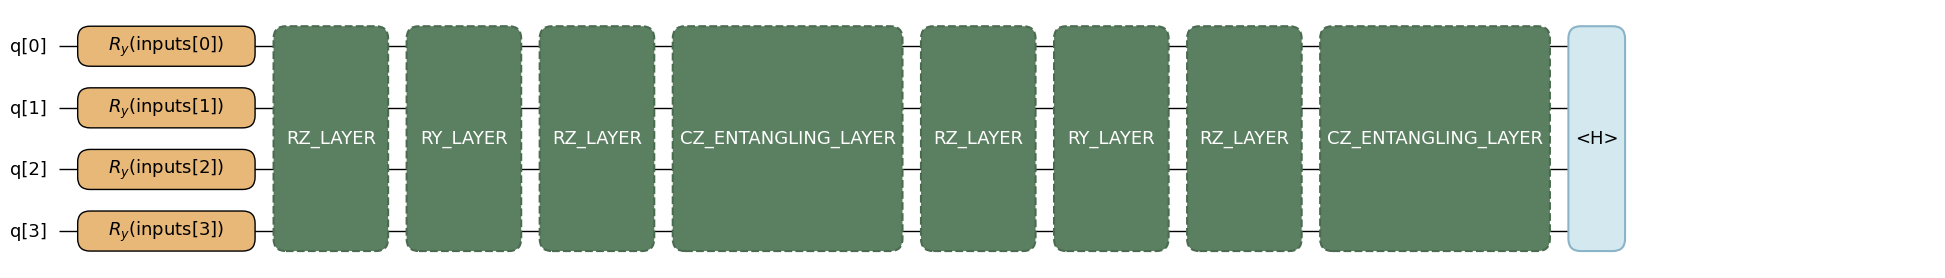

In [6]:
variational_ansatz.draw(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS,
    hamiltonian=qmo.Z(0),
    fold_loops=False,
    inline=False,
)

We define an observable for measuring $\langle Z_i \rangle$ on each qubit. Because
all $Z_i$ observables commute, Aer can evaluate them together with one circuit
execution. Qiskit's estimator requires each observable to have the same number of
qubits as the circuit, so `Hamiltonian(num_qubits=...)` supplies the unaffected
qubits. We then transpile the parameterized variational circuit only once and
convert the observables to Qiskit's representation. Finally, we send the circuit,
observables, and parameter values to Aer as a single execution unit (PUB).
`estimate_resources()` reports gate counts without directly accessing the
transpiled circuit.

In [7]:
observables = []
for i in range(N_QUBITS):
    obs = qmo.Hamiltonian(num_qubits=N_QUBITS)
    obs.add_term((qmo.PauliOperator(qmo.Pauli.Z, i),), 1.0)
    observables.append(obs)

transpiler = QiskitTranspiler()

executable = transpiler.transpile(
    variational_ansatz,
    bindings={
        "n_qubits": N_QUBITS,
        "n_layers": N_LAYERS,
        "hamiltonian": observables[0],
    },
    parameters=["inputs", "weights"],
)
qiskit_circuit = executable.get_first_circuit()
assert qiskit_circuit is not None
parameter_metadata = executable.compiled_quantum[0].parameter_metadata
qiskit_observables = [
    hamiltonian_to_sparse_pauli_op(observable) for observable in observables
]
aer_estimator = AerEstimator(
    options={"backend_options": {"method": "statevector"}},
)

est = variational_ansatz.estimate_resources(
    inputs={"n_qubits": N_QUBITS, "n_layers": N_LAYERS},
)
print(est)
assert est.qubits == 4
# 4 (input RY encoding) + 2 layers * (4 RZ + 4 RY + 4 RZ) = 28 single-qubit rotations.
assert est.gates.single_qubit == 28
# 2 layers * 3 CZs (linear chain on 4 qubits) = 6 two-qubit Cliffords.
assert est.gates.two_qubit == 6
assert est.gates.total == 34
assert est.gates.rotation_gates == 28

ResourceEstimate(width=WidthResources(input_qubits=0, allocated_qubits=4, clean_ancilla_qubits=0, dirty_ancilla_qubits=0, peak_qubits=4), gates=GateResources(total=34, single_qubit=28, two_qubit=6, multi_qubit=0, clifford=6, rotation=28, t=0, toffoli=0, non_clifford=28), depth=DepthResources(depth=34, clifford_depth=6, rotation_depth=28, t_depth=0, toffoli_depth=0, non_clifford_depth=28, measurement_depth=0), calls=CallResources(calls_by_name={}, queries_by_name={}), assumptions=(), trace=None, parameters={}, quality=<EstimateQuality.UPPER_BOUND: 'upper_bound'>)


The forward pass maps concrete values to the parameters emitted by Qamomile and
sends the circuit, bindings, and all commuting $Z_i$ observables to Aer as one PUB.
Aer adds every expectation value to the same simulation, so each forward pass uses
one backend execution instead of one execution per qubit.

In [8]:
def quantum_forward(input_vals: np.ndarray, weight_vals: np.ndarray) -> np.ndarray:
    """Evaluate <Z_i> for each qubit given inputs and weights.

    Args:
        input_vals: Feature values, shape (N_QUBITS,).
        weight_vals: Trainable weights, shape (N_WEIGHTS,).

    Returns:
        Expectation values, shape (N_QUBITS,).
    """
    indexed_bindings = {
        **{f"inputs[{i}]": float(value) for i, value in enumerate(input_vals)},
        **{f"weights[{i}]": float(value) for i, value in enumerate(weight_vals)},
    }
    qiskit_bindings = parameter_metadata.to_binding_dict(indexed_bindings)
    result = aer_estimator.run(
        [
            (qiskit_circuit, qiskit_observables, qiskit_bindings),
        ]
    ).result()
    return np.asarray(result[0].data.evs, dtype=float)

In [9]:
# Quick test: random inputs and weights
rng = np.random.default_rng(42)
test_inputs = rng.uniform(-np.pi, np.pi, N_QUBITS)
test_weights = rng.uniform(-np.pi, np.pi, N_WEIGHTS)

expvals = quantum_forward(test_inputs, test_weights)
print("Expectation values:", expvals)
# Z expectation values are bounded in [-1, 1]; one value per qubit.
assert expvals.shape == (N_QUBITS,)
assert all(-1.0 <= float(e) <= 1.0 for e in expvals)

Expectation values: [-0.70960489  0.61071606  0.43586927  0.42650987]


#### Gradient Computation: Parameter Shift

Neural networks are commonly trained with gradient descent, which updates parameters in the direction indicated by the gradient of the loss function. The same principle applies to a quantum circuit layer: backpropagating the loss requires the gradient of the Hamiltonian expectation value $\langle H \rangle$ with respect to each circuit parameter.

On a quantum device, an expectation value is estimated from a finite number of measurements. Training therefore requires an unbiased gradient estimator, whose mean equals the true gradient. For a gate of the form $e^{-i\theta G/2}$ whose generator $G$ has eigenvalues $\pm 1$, the **parameter shift rule** {cite:p}`10.1103/PhysRevA.98.032309,10.1103/PhysRevA.99.032331` gives an exact relation that computes the gradient from two expectation values evaluated at positively and negatively shifted parameter values:

$$
\frac{\partial}{\partial \theta_k} \langle H \rangle
= \frac{1}{2} \Big[
    \langle H \rangle\big|_{\theta_k + \pi/2}
  - \langle H \rangle\big|_{\theta_k - \pi/2}
\Big]
$$

Unbiased estimates of the two expectation values therefore give an unbiased estimator of the expectation-value gradient. In this tutorial, we set $H=Z_i$ and evaluate the expectation value for each qubit. We implement the rule as a custom `torch.autograd.Function` so that PyTorch can backpropagate through the quantum layer. The implementation uses in-place parameter shifts to avoid allocating copies on every iteration.

In [10]:
SHIFT = math.pi / 2


class QuantumFunction(torch.autograd.Function):
    """Custom autograd function bridging PyTorch and the quantum circuit."""

    @staticmethod
    def forward(ctx, inputs: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
        ctx.save_for_backward(inputs, weights)
        # Evaluate the circuit for each sample in the batch
        batch_results = []
        weights_np = weights.detach().cpu().numpy()
        for inp in inputs:
            expvals = quantum_forward(inp.detach().cpu().numpy(), weights_np)
            batch_results.append(expvals)
        return torch.tensor(
            np.array(batch_results), dtype=inputs.dtype, device=inputs.device
        )

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        inputs, weights = ctx.saved_tensors
        weights_np = weights.detach().cpu().numpy().copy()

        grad_inputs = torch.zeros_like(inputs)
        grad_weights = torch.zeros(
            weights.shape[0], dtype=weights.dtype, device=weights.device
        )

        for b, inp in enumerate(inputs):
            inp_np = inp.detach().cpu().numpy().copy()
            g_out = grad_output[b].detach().cpu().numpy()  # shape (N_QUBITS,)

            # Gradient w.r.t. weights (in-place shift to avoid copies)
            for k in range(len(weights_np)):
                weights_np[k] += SHIFT
                fwd_plus = quantum_forward(inp_np, weights_np)
                weights_np[k] -= 2 * SHIFT
                fwd_minus = quantum_forward(inp_np, weights_np)
                weights_np[k] += SHIFT  # restore

                param_grad = (fwd_plus - fwd_minus) / 2.0  # shape (N_QUBITS,)
                grad_weights[k] += np.dot(g_out, param_grad)

            # Gradient w.r.t. inputs (in-place shift to avoid copies)
            for k in range(len(inp_np)):
                inp_np[k] += SHIFT
                fwd_plus = quantum_forward(inp_np, weights_np)
                inp_np[k] -= 2 * SHIFT
                fwd_minus = quantum_forward(inp_np, weights_np)
                inp_np[k] += SHIFT  # restore

                input_grad = (fwd_plus - fwd_minus) / 2.0
                grad_inputs[b, k] = np.dot(g_out, input_grad)

        return grad_inputs, grad_weights

### HQNN Workflow with PyTorch

We are now ready to integrate the quantum circuit layer into the PyTorch workflow.

We wrap `QuantumFunction`, which defines the quantum circuit's forward and backward propagation, in a standard `nn.Module` so it can be composed with other PyTorch layers. By calling `QuantumFunction.apply` from `QLayer.forward`, ordinary forward propagation evaluates the quantum expectation values, while backpropagation during training automatically invokes the corresponding `backward` operation.

In [11]:
class QLayer(nn.Module):
    """PyTorch module wrapping a Qamomile variational circuit."""

    def __init__(self, n_weights: int):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_weights) * 0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return QuantumFunction.apply(x, self.weights)

Finally, we describe the complete HQNN workflow in PyTorch. A CNN first extracts features from the input image, and the quantum circuit layer processes the reduced feature vector. A classifier then acts on the quantum circuit output to identify the image class. This is the basic workflow; here, we add the following operations to improve training accuracy:

- **Sigmoid function filter**: $\pi \cdot \sigma(\cdot)$ maps the CNN outputs to $(0, \pi)$, bounding the rotation angles supplied to the quantum circuit and reducing angle wrap-around.
- **Feature-level fusion classifier**: The CNN features and quantum circuit outputs are concatenated so that the classifier receives both the classical representation and its quantum-transformed counterpart. Combining features before classification in this way is known as feature-level fusion or feature concatenation.

In [12]:
class EndToEndHybridHQNN(nn.Module):
    """
    End-to-end hybrid model trained from scratch.
    Image -> CNN features -> Quantum layer -> Classifier

    The feature-level fusion classifier takes [classical features, quantum outputs]
    giving the model access to both representations.
    """

    def __init__(self, n_qubits: int, n_weights: int, n_classes: int):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            # Convolution block 1: extract local features and reduce spatial size.
            nn.Conv2d(1, 4, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Convolution block 2: refine the features and reduce spatial size again.
            nn.Conv2d(4, 4, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Feature reduction: project the feature map to one value per qubit.
            nn.Flatten(),
            nn.Linear(7 * 7 * 4, n_qubits),
        )
        # Quantum circuit layer: transform the reduced features into expectations.
        self.qlayer = QLayer(n_weights)
        # Feature-level fusion classifier: predict from CNN and quantum features.
        self.classifier = nn.Linear(n_qubits * 2, n_classes)

    def forward(self, x: torch.Tensor):
        # Extract CNN features and map them to circuit angles with the sigmoid filter.
        feats = math.pi * torch.sigmoid(
            self.feature_extractor(x)
        )  # shape: (B, N_QUBITS)
        # Run the quantum circuit layer to obtain one expectation per qubit.
        q_out = self.qlayer(feats)  # shape: (B, N_QUBITS)

        # Concatenate CNN features and quantum outputs for feature-level fusion.
        fused = torch.cat([feats, q_out], dim=1)  # shape: (B, 2*N_QUBITS)
        # Map the fused features to one logit per class.
        logits = self.classifier(fused)
        return logits, feats, q_out

## Results

Here, we train the HQNN on the Fashion-MNIST training data and evaluate its classification performance on the test data. In addition to tracking the training loss and test accuracy, we inspect the gradients after training, per-class accuracy, the confusion matrix, and individual predictions.

### Training

We train the hybrid model for 10 epochs with cross-entropy loss and the Adam optimizer. Each update differentiates both the classical network and the quantum circuit. After training, we explicitly confirm that gradients have reached the first CNN convolution and the trainable quantum weights.

In [13]:
EPOCHS = 2 if docs_test_mode else 10
BATCH_SIZE = 4

torch.manual_seed(42)
hybrid_model = EndToEndHybridHQNN(N_QUBITS, N_WEIGHTS, N_CLASSES)

optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
test_accs = []

print(f"=== End-to-End Training ({EPOCHS} epochs) ===")
for epoch in range(EPOCHS):
    perm = torch.randperm(len(X_train))
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_loss = 0.0
    total = 0

    for i in range(0, len(X_shuf), BATCH_SIZE):
        xb = X_shuf[i : i + BATCH_SIZE]
        yb = y_shuf[i : i + BATCH_SIZE]

        optimizer.zero_grad()
        logits, feats, q_out = hybrid_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total += len(yb)

    avg_loss = epoch_loss / max(1, math.ceil(total / BATCH_SIZE))
    train_losses.append(avg_loss)

    with torch.no_grad():
        test_logits, _, _ = hybrid_model(X_test)
        test_acc = (test_logits.argmax(1) == y_test).float().mean().item()
        test_accs.append(test_acc)

    print(f"  Epoch {epoch + 1}/{EPOCHS}  loss={avg_loss:.4f}  test_acc={test_acc:.2%}")

# Fixed dataset and model seeds make the full tutorial result deterministic.
if not docs_test_mode:
    assert train_losses[-1] < train_losses[0]
    assert math.isclose(test_accs[-1], 0.975, rel_tol=0.0, abs_tol=1e-6)

=== End-to-End Training (10 epochs) ===


  Epoch 1/10  loss=1.3356  test_acc=55.83%


  Epoch 2/10  loss=0.9415  test_acc=97.50%


  Epoch 3/10  loss=0.6617  test_acc=97.50%


  Epoch 4/10  loss=0.5081  test_acc=96.67%


...

  Epoch 6/10  loss=0.3461  test_acc=96.67%


  Epoch 7/10  loss=0.3025  test_acc=96.67%


  Epoch 8/10  loss=0.2675  test_acc=96.67%


  Epoch 9/10  loss=0.2436  test_acc=96.67%


  Epoch 10/10  loss=0.2324  test_acc=97.50%


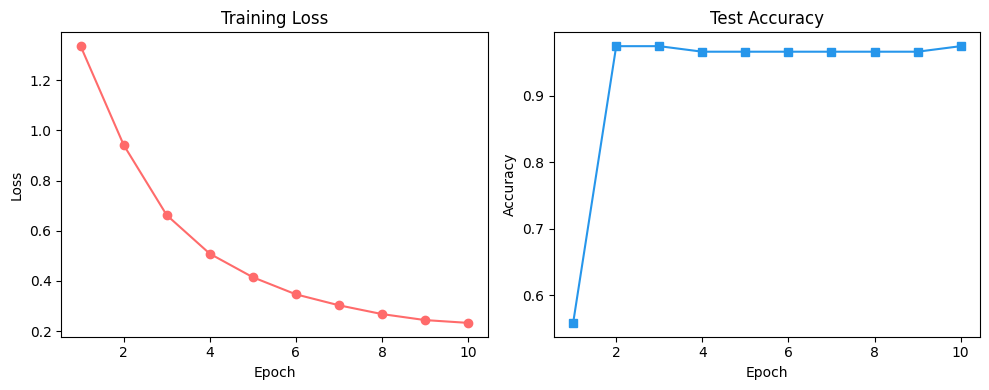

In [14]:
# Learning curves
_, axes = plt.subplots(1, 2, figsize=(10, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, "o-", color="#FF6B6B")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")

axes[1].plot(epochs_range, test_accs, "s-", color="#2696EB")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Test Accuracy")

plt.tight_layout()
plt.show()

In [15]:
# Verify gradients flow to both CNN and quantum layer
xb = X_train[:BATCH_SIZE]
yb = y_train[:BATCH_SIZE]

optimizer.zero_grad()
logits, feats, q_out = hybrid_model(xb)
loss = criterion(logits, yb)
loss.backward()

# ``loss.backward()`` populates ``.grad`` on each parameter; assert here
# so the torch stubs that declare ``.grad`` as ``Tensor | None`` narrow.
# ``nn.Sequential.__getitem__`` is typed as
# ``Tensor | None | Module`` in the torch stub (it accepts both indices
# and slices), so narrow to ``nn.Module`` explicitly before grabbing the
# layer's ``.weight``.
first_conv = hybrid_model.feature_extractor[0]
assert isinstance(first_conv, torch.nn.Module)
first_conv_weight = first_conv.weight  # type: ignore[union-attr]
assert first_conv_weight.grad is not None
quantum_grad = hybrid_model.qlayer.weights.grad
assert quantum_grad is not None
print(
    "feature_extractor first conv grad mean:",
    # zuban treats the chained ``.grad.abs()`` on a stub-typed Tensor as
    # "Tensor not callable"; the runtime call is the standard
    # ``Tensor.abs`` method which produces a Tensor.
    first_conv_weight.grad.abs().mean().item(),  # type: ignore[operator]
)
print("quantum weights grad mean:", quantum_grad.abs().mean().item())

optimizer.zero_grad()

feature_extractor first conv grad mean: 0.07927611470222473
quantum weights grad mean: 0.009609604254364967


### Evaluation

We apply the trained model to the test data and examine both overall and per-class accuracy. We then use the confusion matrix to identify patterns of confusion between classes and sample predictions to inspect the model's decisions on individual images.

In [16]:
with torch.no_grad():
    q_logits, F_test_e2e, q_outputs = hybrid_model(X_test)
    preds = q_logits.argmax(1)
    quantum_acc = (preds == y_test).float().mean().item()

print(f"End-to-end quantum model accuracy: {quantum_acc:.2%}")
print()

for c in range(N_CLASSES):
    mask = y_test == c
    class_acc = (preds[mask] == y_test[mask]).float().mean().item()
    print(f"  {CLASS_NAMES[c]}: {class_acc:.2%}")

End-to-end quantum model accuracy: 97.50%

  T-shirt: 96.67%
  Trouser: 100.00%
  Sandal: 100.00%
  Bag: 93.33%


A confusion matrix places the true classes along its rows and the classes predicted by the model along its columns. Each entry gives the number of images with that combination. Diagonal entries count correctly classified images, while off-diagonal entries count misclassifications and reveal which classes the model tends to confuse.

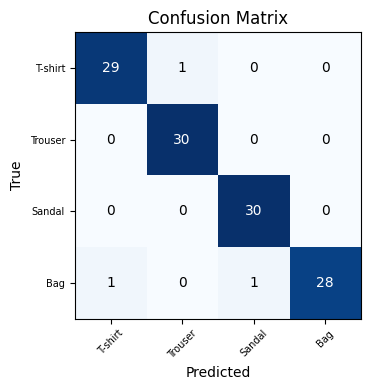

In [17]:
# Confusion matrix
conf = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for t, p in zip(y_test.numpy(), preds.numpy()):
    conf[t, p] += 1
if not docs_test_mode:
    expected_conf = np.array(
        [
            [29, 1, 0, 0],
            [0, 30, 0, 0],
            [0, 0, 30, 0],
            [1, 0, 1, 28],
        ]
    )
    np.testing.assert_array_equal(conf, expected_conf)
_, ax = plt.subplots(figsize=(5, 4))
ax.imshow(conf, cmap="Blues")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, fontsize=7, rotation=45)
ax.set_yticklabels(CLASS_NAMES, fontsize=7)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(
            j,
            i,
            str(conf[i, j]),
            ha="center",
            va="center",
            color="white" if conf[i, j] > conf.max() / 2 else "black",
        )
plt.tight_layout()
plt.show()

The confusion matrix shows that the model correctly classifies 117 of the 120 test samples. Every Trouser and Sandal sample is correct; one T-shirt is classified as Trouser, while one Bag is classified as T-shirt and another as Sandal. The concentration of predictions along the diagonal indicates that the model distinguishes the four selected classes with high accuracy.

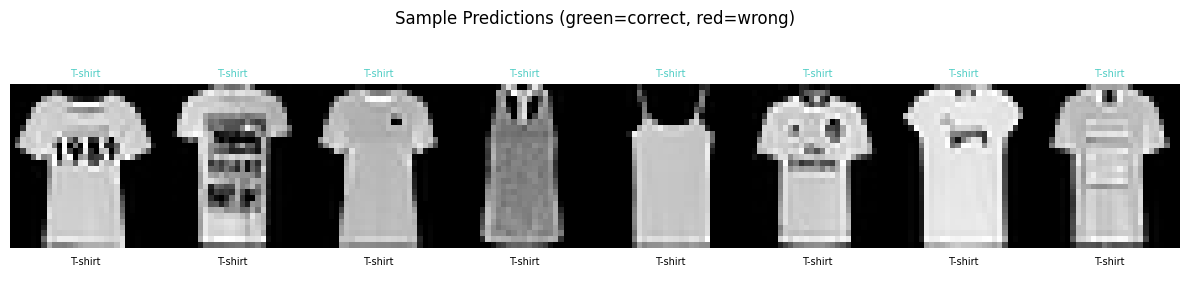

In [18]:
# Sample images with predictions
n_show = min(8, len(X_test))
sample_imgs = X_test[:n_show, 0].numpy()
if not docs_test_mode:
    assert torch.equal(y_test[:n_show], torch.zeros(n_show, dtype=y_test.dtype))
    assert torch.equal(preds[:n_show], y_test[:n_show])
combined = np.concatenate(sample_imgs, axis=1)
_, ax = plt.subplots(figsize=(12, 3))
ax.imshow(combined, cmap="gray", aspect="auto")
for i in range(n_show):
    color = "#4ECDC4" if preds[i] == y_test[i] else "#FF6B6B"
    ax.text(
        28 * i + 14,
        -1.5,
        CLASS_NAMES[preds[i].item()],
        ha="center",
        va="bottom",
        fontsize=7,
        color=color,
        clip_on=False,
    )
    # ``Tensor.item()`` is typed as ``int | float | bool`` in the torch
    # stub even for an integer-typed tensor; the runtime value here is
    # always an ``int`` class label, so cast explicitly for the list index.
    ax.text(
        28 * i + 14,
        29,
        CLASS_NAMES[int(y_test[i].item())],
        ha="center",
        va="top",
        fontsize=7,
        clip_on=False,
    )
ax.set_ylim(33, -8)
ax.set_title("Sample Predictions (green=correct, red=wrong)", pad=12)
ax.axis("off")

plt.tight_layout()
plt.show()

For all eight displayed examples, both the true label and predicted label are T-shirt. Every prediction label above the images is therefore shown in green, confirming that the model correctly identifies these samples.

## Summary

In this notebook, we:

- **Studied the HQNN workflow**: a classical CNN extracts image features, a variational quantum circuit transforms them, and a feature-level fusion classifier predicts the image class.
- **Integrated Qamomile with PyTorch**: Qamomile defines the ansatz and expectation-value evaluation, while parameter-shift `forward` and `backward` operations connect the quantum circuit layer to PyTorch autograd for end-to-end training.
- **Trained and evaluated the model**: on the four-class Fashion-MNIST task, the training loss decreases over the epochs and the model reaches 97.5% test accuracy. The confusion matrix and sample predictions also show that it distinguishes the selected classes accurately.